学習器をXGBoostからRandomForestに変更　（グリッドサーチ）

In [30]:
from pathlib import Path
import numpy as np
import pandas as pd
import os
import re
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy.stats import mode
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

#1.------前処理------

#表情データの読み込みとdfに格納
folder_path = Path('../../../output_filtered_questions_copy')

file_list = folder_path.glob('*.csv')

file_path_list = [str(p) for p in file_list]

df = pd.DataFrame(file_path_list, columns=['filepath'])

files_df = df
files_df['filename'] = df['filepath'].apply(lambda p: Path(p).name)
files_df['ID'] = files_df['filename'].str.extract(r'ID(\d+)')
files_df['ID'] = files_df['ID'].astype(int)

#患者の疾患有無
labels_df = pd.read_csv(r"C:\Users\robotics\proj\Research\code\voice\delirium.csv")
#患者と疾患有無を結合
file_with_labels_df = pd.merge(files_df, labels_df, on='ID', how='left')
file_with_labels_df.drop(columns=['Sex'], inplace=True)

#print(file_with_labels_df)

#学習・テストデータとなるファイルの分割
X_files = file_with_labels_df.drop(columns='Delirum', errors='ignore')
#print(X_files)
y_labels = file_with_labels_df.drop(columns=['filepath', 'filename'], errors='ignore')
#print(y_labels)
#80%学習データ、20%テストデータに分割（患者単位）
X_train, X_test, y_train, y_test = train_test_split(
    X_files, y_labels, test_size=0.2, random_state=42, stratify=y_labels['Delirium']
)

#print(X_train)
#print(y_train)

#順番をソート
X_train_sort = X_train.sort_values(by='ID', ascending=True)
X_test_sort = X_test.sort_values(by='ID', ascending=True)
y_train_sort = y_train.sort_values(by='ID', ascending=True).drop(columns='ID', errors='ignore')
y_test_sort = y_test.sort_values(by='ID', ascending=True).drop(columns='ID', errors='ignore')
#print(X_test_sort)

#2.------学習データを読み込み、質問ごとの最大値を計算------

train_file_path = [f for f in X_train_sort['filepath']]
#print(train_file_path)
train_df = pd.DataFrame()
for f, a in zip(train_file_path, y_train_sort['Delirium']):
    df_train_file = pd.read_csv(f)
    #print(df_train_file)
    #ファイル名とラベルの付与
    current_filename = os.path.basename(f)
    #ファイル名の数字部分を抽出
    number = re.findall(r'\d+', current_filename)
    #print(number)
    df_train_file['Delirium'] = a
    df_train_file['filenumber'] = number[0]
    #print(df_train_file)  
     
    #必要のない列の削除
    #label列にある空白の削除
    df_train_file['label'] = df_train_file['label'].astype(str).str.strip()
    
    #応答部分のAUだけを抽出
    df_train_sort_df = df_train_file[df_train_file['label'].str.match('^answer(10|[1-9])$', na=False)]
    confidence = df_train_sort_df['Confidence'] <= 0.90
    rows_to_delete = df_train_sort_df[confidence].index
    df_train_new_df = df_train_sort_df.drop(rows_to_delete)
    columns_to_extract = ["label"] + [col for col in df_train_new_df.columns if col.startswith("AU")] + ["Delirium", "filenumber"]
    df_train_final_df = df_train_new_df[columns_to_extract]

    #print(df_train_final_df)

    columns_to_AU = ["AU07", "AU11", "AU20"]

    #AU07, 11, 20の削除
    df_train_final_df = df_train_final_df.drop(columns=columns_to_AU, errors='ignore')
    #print(df_train_final_df)

    #数値型に変更
    #df_train_final_df['filename'] = pd.to_numeric(df_train_final_df['filename'], errors='coerce')
    #print(df_train_final_df)

    #質問ごとの最大値を計算
    df_train_max_df = df_train_final_df.groupby('label').max()
    df_train_max_df = df_train_max_df.reset_index(drop=True)
    #print(df_train_max_df)

    train_df = pd.concat([train_df, df_train_max_df], ignore_index=True)

#print(train_df)

#3.------テストデータを読み込み、質問ごとの最大値を計算------

test_file_path = [f for f in X_test_sort['filepath']]
#print(test_file_path)
test_df = pd.DataFrame()
test_file_lengths = []
for f, a in zip(test_file_path, y_test_sort['Delirium']):
    df_test_file = pd.read_csv(f)
    #print(df_test_file)
    #ファイル名とラベルの付与
    current_filename = os.path.basename(f)
    #print(current_filename)
    df_test_file['Delirium'] = a
    df_test_file['filename'] = current_filename
    #print(df_test_file)  
     
    #必要のない列の削除
    #label列にある空白の削除
    df_test_file['label'] = df_test_file['label'].astype(str).str.strip()
    
    #応答部分のAUだけを抽出
    df_test_sort_df = df_test_file[df_test_file['label'].str.match('^answer(10|[1-9])$', na=False)]
    confidence = df_test_sort_df['Confidence'] <= 0.90
    rows_to_delete = df_test_sort_df[confidence].index
    df_test_new_df = df_test_sort_df.drop(rows_to_delete)
    columns_to_extract = ["label"] + [col for col in df_test_new_df.columns if col.startswith("AU")] + ["Delirium", "filename"]
    df_test_final_df = df_test_new_df[columns_to_extract]

    #print(df_test_final_df)

    columns_to_AU = ["AU07", "AU11", "AU20"]

    #AU07, 11, 20の削除
    df_test_final_df = df_test_final_df.drop(columns=columns_to_AU, errors='ignore')
    #print(df_test_final_df)

    #数値型に変更
    #df_test_final_df['filename'] = pd.to_numeric(df_test_final_df['filename'], errors='coerce')
    #print(df_test_final_df)

    #質問ごとの最大値を計算
    df_test_max_df = df_test_final_df.groupby('label').max()
    df_test_max_df = df_test_max_df.reset_index(drop=True)
    #print(df_test_max_df)
    
    test_file_lengths.append(len(df_test_max_df))

    test_df = pd.concat([test_df, df_test_max_df], ignore_index=True)

print(test_df)
#print(test_file_lengths)

#4.------グリッドサーチのための学習・検証データの用意とテストデータの用意------

y_train_grid = train_df['Delirium']
y_test_grid = test_df['Delirium']

columns_to_delete = ['Delirium']
columns_to_delete2 = ['Delirium', 'filename']

X_train_grid = train_df.drop(columns=columns_to_delete, errors='ignore')
X_test_grid = test_df.drop(columns=columns_to_delete2, errors='ignore')




#print(X_train_grid)

#5.------学習の準備(学習器と学習方法の設定)------

#患者ごとに分割するための変数を用意し、学習データからfilenumberを削除
patient_groups = X_train_grid['filenumber'].values
X_train_model = X_train_grid.drop(columns=['filenumber']).copy()

print(X_train_model)

#モデル・グリッドサーチの定義
model = RandomForestClassifier(random_state=42)
cv = GroupKFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10]
    }
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring='accuracy', cv=cv, n_jobs=-1)

#6.------グリッドサーチ------
grid_search.fit(X_train_model, y_train_grid, groups=patient_groups)

print(f"最適なハイパーパラメータ：{grid_search.best_params_}")
print(f"CVでのmax精度(Accuracy):{grid_search.best_score_:.4f}")

#行と列の表示制限を解除（または十分に大きな値に設定）
pd.set_option('display.max_rows', None)     # すべての行を表示
pd.set_option('display.max_columns', None)  # すべての列を表示
pd.set_option('display.width', 1000)        # 表示幅を広くする

#結果をDataFrameに変換し表示
results_df = pd.DataFrame(grid_search.cv_results_)

print("--- グリッドサーチの全試行結果 ---")
print(results_df)

#表示設定を元に戻す (推奨)
#グローバルな設定を元に戻し、他の処理に影響を与えないようにします
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.width')


#7.------テストデータでの性能評価------
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_grid)
final_accuracy = accuracy_score(y_test_grid, y_pred)

print(f"テストデータでの正解率: {final_accuracy:.4}\n")
#print(y_pred)

file_predictions = []
start_idx = 0
for length in test_file_lengths:
    end_idx = start_idx + length
    predictions_for_this_file = y_pred[start_idx:end_idx]
    majority_vote = mode(predictions_for_this_file)[0]
    file_predictions.append([majority_vote, start_idx, end_idx])
    start_idx = end_idx

first_column_list = [item[0] for item in file_predictions]

#print(first_column_list)

y_test_files = X_test_sort['Delirium'].values

#print(type(y_test_files))

y_test_files_copy = X_test_sort

y_test_files_copy = y_test_files_copy.assign(Predictions=first_column_list)

print("各テストファイルごとの分類結果\n")
print(y_test_files_copy.drop(columns=['filepath'], errors='ignore'))

correct_files = np.sum(np.array(first_column_list) == y_test_files)
total_files = len(X_test_sort)
file_accuracy = correct_files/ total_files

scores = []
scores.append(file_accuracy)
print("\n")
print(f"正解率 (ファイル単位): {file_accuracy:.4f} ({correct_files}/{total_files} ファイル正解)\n")


#8.------混同行列の作成------
cm = confusion_matrix(y_test_files, first_column_list)
cm_df = pd.DataFrame(cm, 
                     index=['正解: 0', '正解: 1'], 
                     columns=['予測: 0', '予測: 1'])

print("混同行列:")
print(cm_df)
print("\n") # 見やすいように改行

#特徴量の重要度を取得
feature_names = X_train_model.columns.tolist()
    
importances = best_model.feature_importances_

#特徴量の名前と重要度をまとめたDataFrameを作成
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

#重要度が高い順にソート
sorted_importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(sorted_importance_df)




         AU01      AU02      AU04  ...      AU43  Delirium           filename
0    0.777489  0.535435  0.578409  ...  0.824882         0  filtered_ID38.csv
1    0.794272  0.620501  0.734319  ...  0.945924         0  filtered_ID38.csv
2    0.777211  0.489627  0.368145  ...  0.387591         0  filtered_ID38.csv
3    0.725350  0.470209  0.544369  ...  0.769619         0  filtered_ID38.csv
4    0.766321  0.494406  0.528994  ...  0.952642         0  filtered_ID38.csv
..        ...       ...       ...  ...       ...       ...                ...
114  0.797877  0.591720  0.545756  ...  0.930093         1  filtered_ID94.csv
115  0.813775  0.651270  0.828008  ...  0.941779         1  filtered_ID94.csv
116  0.785423  0.621684  0.652966  ...  0.935042         1  filtered_ID94.csv
117  0.793317  0.583096  0.614829  ...  0.916454         1  filtered_ID94.csv
118  0.809973  0.641156  0.749186  ...  0.944586         1  filtered_ID94.csv

[119 rows x 19 columns]
         AU01      AU02      AU04  ... 

SHAP Values (全体)の形状 : (475, 17, 2)
SHAP Values (全体)の形状 : (475, 17)


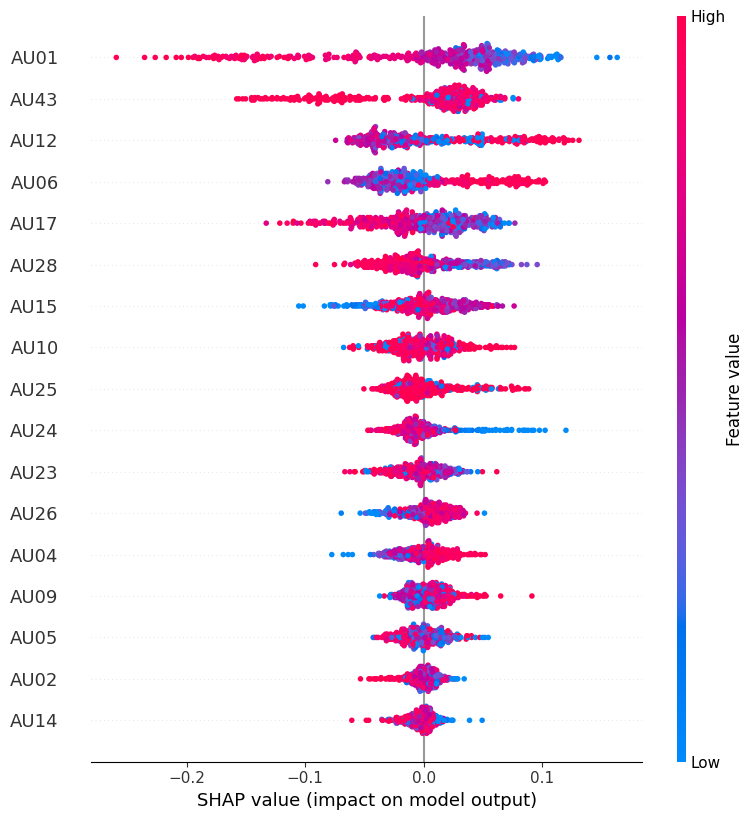

In [3]:
import shap

#print(X_train_model)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_train_model)

print(f"SHAP Values (全体)の形状 : {shap_values.shape}")

shap_values_class1 = shap_values[:, :, 1]

print(f"SHAP Values (全体)の形状 : {shap_values_class1.shape}")

shap.summary_plot(shap_values_class1, X_train_model, max_display=17)

shap.initjs()

In [4]:
import pandas as pd
import numpy as np

# SHAP値 (475行, 17列) を使用
# X_train_model は特徴量名を持つDataFrame
# shap_values_class1 は 2D NumPy配列

# 各特徴量（列）のSHAP値の絶対値の平均を計算 (axis=0で行方向の平均)
avg_abs_shap = np.abs(shap_values_class1).mean(axis=0)

# DataFrameを作成
df_importance = pd.DataFrame({
    '特徴量名': X_train_model.columns, # 列に特徴量名
    '平均絶対SHAP値': avg_abs_shap
})

# 貢献度の高い順に並べ替え
df_importance_ranked = df_importance.sort_values(by='平均絶対SHAP値', ascending=False)

print("--- 特徴量（列）ごとの平均絶対SHAP値ランキング ---")
print(df_importance_ranked)

--- 特徴量（列）ごとの平均絶対SHAP値ランキング ---
    特徴量名  平均絶対SHAP値
0   AU01   0.064283
16  AU43   0.044137
7   AU12   0.041586
4   AU06   0.034567
10  AU17   0.031902
15  AU28   0.026324
9   AU15   0.022761
6   AU10   0.018907
13  AU25   0.018512
12  AU24   0.015537
11  AU23   0.015505
14  AU26   0.014820
2   AU04   0.014543
5   AU09   0.013206
3   AU05   0.012894
1   AU02   0.008549
8   AU14   0.008222


クロスバリデーション＋グリッドサーチ

In [27]:
from pathlib import Path
import numpy as np
import pandas as pd
import os
import re
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy.stats import mode
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt


#1.------前処理------

#表情データの読み込みとdfに格納
folder_path = Path('../../../output_filtered_questions_copy')

file_list = folder_path.glob('*.csv')

file_path_list = [str(p) for p in file_list]

df = pd.DataFrame(file_path_list, columns=['filepath'])

files_df = df
files_df['filename'] = df['filepath'].apply(lambda p: Path(p).name)
files_df['ID'] = files_df['filename'].str.extract(r'ID(\d+)')
files_df['ID'] = files_df['ID'].astype(int)

#患者の疾患有無
labels_df = pd.read_csv(r"C:\Users\robotics\proj\Research\code\voice\delirium.csv")
#患者と疾患有無を結合
file_with_labels_df = pd.merge(files_df, labels_df, on='ID', how='left')
file_with_labels_df.drop(columns=['Sex'], inplace=True)

#print(file_with_labels_df)

#学習・テストデータとなるファイルの分割
X_files = file_with_labels_df.drop(columns='Delirum', errors='ignore')
#print(X_files)
y_labels = file_with_labels_df.drop(columns=['filepath', 'filename', 'ID'], errors='ignore')
#rint(y_labels)

#層化５分割交差検証
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_index, test_index) in enumerate(skf.split(X_files, y_labels)):
    X_train_sort, X_test_sort = X_files.iloc[train_index], X_files.iloc[test_index]
    y_train_sort, y_test_sort = y_labels.iloc[train_index], y_labels.iloc[test_index]

    #2.------学習データを読み込み、質問ごとの最大値を計算------

    train_file_path = [f for f in X_train_sort['filepath']]
    #print(train_file_path)
    train_df = pd.DataFrame()
    for f, a in zip(train_file_path, y_train_sort['Delirium']):
        df_train_file = pd.read_csv(f)
        #print(df_train_file)
        #ファイル名とラベルの付与
        current_filename = os.path.basename(f)
        #ファイル名の数字部分を抽出
        number = re.findall(r'\d+', current_filename)
        #print(number)
        df_train_file['Delirium'] = a
        df_train_file['filenumber'] = number[0]
        #print(df_train_file)  
        
        #必要のない列の削除
        #label列にある空白の削除
        df_train_file['label'] = df_train_file['label'].astype(str).str.strip()
        
        #応答部分のAUだけを抽出
        df_train_sort_df = df_train_file[df_train_file['label'].str.match('^answer(10|[1-9])$', na=False)]
        confidence = df_train_sort_df['Confidence'] <= 0.90
        rows_to_delete = df_train_sort_df[confidence].index
        df_train_new_df = df_train_sort_df.drop(rows_to_delete)
        columns_to_extract = ["label"] + [col for col in df_train_new_df.columns if col.startswith("AU")] + ["Delirium", "filenumber"]
        df_train_final_df = df_train_new_df[columns_to_extract]

        #print(df_train_final_df)

        columns_to_AU = ["AU07", "AU11", "AU20"]

        #AU07, 11, 20の削除
        df_train_final_df = df_train_final_df.drop(columns=columns_to_AU, errors='ignore')
        #print(df_train_final_df)

        #数値型に変更
        #df_train_final_df['filename'] = pd.to_numeric(df_train_final_df['filename'], errors='coerce')
        #print(df_train_final_df)

        #質問ごとの最大値を計算
        df_train_max_df = df_train_final_df.groupby('label').max()
        df_train_max_df = df_train_max_df.reset_index(drop=True)
        #print(df_train_max_df)

        train_df = pd.concat([train_df, df_train_max_df], ignore_index=True)

    #print(train_df)

    #3.------テストデータを読み込み、質問ごとの最大値を計算------

    test_file_path = [f for f in X_test_sort['filepath']]
    #print(test_file_path)
    test_df = pd.DataFrame()
    test_file_lengths = []
    for f, a in zip(test_file_path, y_test_sort['Delirium']):
        df_test_file = pd.read_csv(f)
        #print(df_test_file)
        #ファイル名とラベルの付与
        current_filename = os.path.basename(f)
        #print(current_filename)
        df_test_file['Delirium'] = a
        df_test_file['filename'] = current_filename
        #print(df_test_file)  
        
        #必要のない列の削除
        #label列にある空白の削除
        df_test_file['label'] = df_test_file['label'].astype(str).str.strip()
        
        #応答部分のAUだけを抽出
        df_test_sort_df = df_test_file[df_test_file['label'].str.match('^answer(10|[1-9])$', na=False)]
        confidence = df_test_sort_df['Confidence'] <= 0.90
        rows_to_delete = df_test_sort_df[confidence].index
        df_test_new_df = df_test_sort_df.drop(rows_to_delete)
        columns_to_extract = ["label"] + [col for col in df_test_new_df.columns if col.startswith("AU")] + ["Delirium", "filename"]
        df_test_final_df = df_test_new_df[columns_to_extract]

        #print(df_test_final_df)

        columns_to_AU = ["AU07", "AU11", "AU20"]

        #AU07, 11, 20の削除
        df_test_final_df = df_test_final_df.drop(columns=columns_to_AU, errors='ignore')
        #print(df_test_final_df)

        #数値型に変更
        #df_test_final_df['filename'] = pd.to_numeric(df_test_final_df['filename'], errors='coerce')
        #print(df_test_final_df)

        #質問ごとの最大値を計算
        df_test_max_df = df_test_final_df.groupby('label').max()
        df_test_max_df = df_test_max_df.reset_index(drop=True)
        #print(df_test_max_df)
        
        test_file_lengths.append(len(df_test_max_df))

        test_df = pd.concat([test_df, df_test_max_df], ignore_index=True)

    #print(test_df)
    #print(test_file_lengths)

    #4.------グリッドサーチのための学習・検証データの用意とテストデータの用意------

    y_train_grid = train_df['Delirium']
    y_test_grid = test_df['Delirium']

    columns_to_delete = ['Delirium']
    columns_to_delete2 = ['Delirium', 'filename']

    X_train_grid = train_df.drop(columns=columns_to_delete, errors='ignore')
    X_test_grid = test_df.drop(columns=columns_to_delete2, errors='ignore')




    #print(X_train_grid)

    #5.------学習の準備(学習器と学習方法の設定)------

    #患者ごとに分割するための変数を用意し、学習データからfilenumberを削除
    patient_groups = X_train_grid['filenumber'].values
    X_train_model = X_train_grid.drop(columns=['filenumber']).copy()
    #モデル・グリッドサーチの定義
    model = RandomForestClassifier(random_state=42)
    cv = GroupKFold(n_splits=5, shuffle=True, random_state=42)
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 5, 10, 15],
        'min_samples_split': [2, 5, 10]
        }
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring='accuracy', cv=cv, n_jobs=-1)

    #6.------グリッドサーチ------
    grid_search.fit(X_train_model, y_train_grid, groups=patient_groups)
    print(f"---fold{fold+1}---\n")
    print(f"最適なハイパーパラメータ：{grid_search.best_params_}")
    print(f"CVでのmax精度(Accuracy):{grid_search.best_score_:.4f}")

    #行と列の表示制限を解除（または十分に大きな値に設定）
    pd.set_option('display.max_rows', None)     # すべての行を表示
    pd.set_option('display.max_columns', None)  # すべての列を表示
    pd.set_option('display.width', 1000)        # 表示幅を広くする

    #結果をDataFrameに変換し表示
    results_df = pd.DataFrame(grid_search.cv_results_)

    print("--- グリッドサーチの全試行結果 ---")
    print(results_df)

    #表示設定を元に戻す (推奨)
    #グローバルな設定を元に戻し、他の処理に影響を与えないようにします
    pd.reset_option('display.max_rows')
    pd.reset_option('display.max_columns')
    pd.reset_option('display.width')


    #7.------テストデータでの性能評価------
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test_grid)
    final_accuracy = accuracy_score(y_test_grid, y_pred)

    print(f"テストデータでの正解率: {final_accuracy:.4}\n")
    #print(y_pred)

    file_predictions = []
    start_idx = 0
    for length in test_file_lengths:
        end_idx = start_idx + length
        predictions_for_this_file = y_pred[start_idx:end_idx]
        majority_vote = mode(predictions_for_this_file)[0]
        file_predictions.append([majority_vote, start_idx, end_idx])
        start_idx = end_idx

    first_column_list = [item[0] for item in file_predictions]

    #print(first_column_list)

    y_test_files = X_test_sort['Delirium'].values

    #print(type(y_test_files))

    y_test_files_copy = X_test_sort

    y_test_files_copy = y_test_files_copy.assign(Predictions=first_column_list)

    print("各テストファイルごとの分類結果\n")
    print(y_test_files_copy.drop(columns=['filepath'], errors='ignore'))

    correct_files = np.sum(np.array(first_column_list) == y_test_files)
    total_files = len(X_test_sort)
    file_accuracy = correct_files/ total_files

    scores = []
    scores.append(file_accuracy)
    print("\n")
    print(f"正解率 (ファイル単位): {file_accuracy:.4f} ({correct_files}/{total_files} ファイル正解)\n")


    #8.------混同行列の作成------
    cm = confusion_matrix(y_test_files, first_column_list)
    cm_df = pd.DataFrame(cm, 
                        index=['正解: 0', '正解: 1'], 
                        columns=['予測: 0', '予測: 1'])

    print("混同行列:")
    print(cm_df)
    print("\n") # 見やすいように改行

    #特徴量の重要度を取得
    feature_names = X_train_model.columns.tolist()
        
    importances = best_model.feature_importances_

    #特徴量の名前と重要度をまとめたDataFrameを作成
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })

    #重要度が高い順にソート
    sorted_importance_df = importance_df.sort_values(by='Importance', ascending=False)

    print(sorted_importance_df)




---fold1---

最適なハイパーパラメータ：{'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 50}
CVでのmax精度(Accuracy):0.5211
--- グリッドサーチの全試行結果 ---
    mean_fit_time  std_fit_time  mean_score_time  std_score_time param_max_depth  param_min_samples_split  param_n_estimators                                             params  split0_test_score  split1_test_score  split2_test_score  split3_test_score  split4_test_score  mean_test_score  std_test_score  rank_test_score
0        0.114573      0.007540         0.004673        0.000656            None                        2                  50  {'max_depth': None, 'min_samples_split': 2, 'n...           0.485149           0.474747           0.473118           0.584270           0.569892         0.517435        0.049086                3
1        0.242143      0.012632         0.008824        0.001459            None                        2                 100  {'max_depth': None, 'min_samples_split': 2, 'n...           0.475248           0.474747     

Borutaを追加 (乱数でダミーの特徴量を用意し、寄与率の低い特徴量を削除)

In [33]:
from pathlib import Path
import numpy as np
import pandas as pd
import os
import re
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy.stats import mode
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from boruta import BorutaPy


#1.------前処理------

#表情データの読み込みとdfに格納
folder_path = Path('../../../output_filtered_questions_copy')

file_list = folder_path.glob('*.csv')

file_path_list = [str(p) for p in file_list]

df = pd.DataFrame(file_path_list, columns=['filepath'])

files_df = df
files_df['filename'] = df['filepath'].apply(lambda p: Path(p).name)
files_df['ID'] = files_df['filename'].str.extract(r'ID(\d+)')
files_df['ID'] = files_df['ID'].astype(int)

#患者の疾患有無
labels_df = pd.read_csv(r"C:\Users\robotics\proj\Research\code\voice\delirium.csv")
#患者と疾患有無を結合
file_with_labels_df = pd.merge(files_df, labels_df, on='ID', how='left')
file_with_labels_df.drop(columns=['Sex'], inplace=True)

#print(file_with_labels_df)

#学習・テストデータとなるファイルの分割
X_files = file_with_labels_df.drop(columns='Delirum', errors='ignore')
#print(X_files)
y_labels = file_with_labels_df.drop(columns=['filepath', 'filename', 'ID'], errors='ignore')
#rint(y_labels)

#層化５分割交差検証
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_index, test_index) in enumerate(skf.split(X_files, y_labels)):
    X_train_sort, X_test_sort = X_files.iloc[train_index], X_files.iloc[test_index]
    y_train_sort, y_test_sort = y_labels.iloc[train_index], y_labels.iloc[test_index]

    #2.------学習データを読み込み、質問ごとの最大値を計算------

    train_file_path = [f for f in X_train_sort['filepath']]
    #print(train_file_path)
    train_df = pd.DataFrame()
    for f, a in zip(train_file_path, y_train_sort['Delirium']):
        df_train_file = pd.read_csv(f)
        #print(df_train_file)
        #ファイル名とラベルの付与
        current_filename = os.path.basename(f)
        #ファイル名の数字部分を抽出
        number = re.findall(r'\d+', current_filename)
        #print(number)
        df_train_file['Delirium'] = a
        df_train_file['filenumber'] = number[0]
        #print(df_train_file)  
        
        #必要のない列の削除
        #label列にある空白の削除
        df_train_file['label'] = df_train_file['label'].astype(str).str.strip()
        
        #応答部分のAUだけを抽出
        df_train_sort_df = df_train_file[df_train_file['label'].str.match('^answer(10|[1-9])$', na=False)]
        confidence = df_train_sort_df['Confidence'] <= 0.90
        rows_to_delete = df_train_sort_df[confidence].index
        df_train_new_df = df_train_sort_df.drop(rows_to_delete)
        columns_to_extract = ["label"] + [col for col in df_train_new_df.columns if col.startswith("AU")] + ["Delirium", "filenumber"]
        df_train_final_df = df_train_new_df[columns_to_extract]

        #print(df_train_final_df)

        columns_to_AU = ["AU07", "AU11", "AU20"]

        #AU07, 11, 20の削除
        df_train_final_df = df_train_final_df.drop(columns=columns_to_AU, errors='ignore')
        #print(df_train_final_df)

        #数値型に変更
        #df_train_final_df['filename'] = pd.to_numeric(df_train_final_df['filename'], errors='coerce')
        #print(df_train_final_df)

        #質問ごとの最大値を計算
        df_train_max_df = df_train_final_df.groupby('label').max()
        df_train_max_df = df_train_max_df.reset_index(drop=True)
        #print(df_train_max_df)

        train_df = pd.concat([train_df, df_train_max_df], ignore_index=True)

    #print(train_df)

    #3.------テストデータを読み込み、質問ごとの最大値を計算------

    test_file_path = [f for f in X_test_sort['filepath']]
    #print(test_file_path)
    test_df = pd.DataFrame()
    test_file_lengths = []
    for f, a in zip(test_file_path, y_test_sort['Delirium']):
        df_test_file = pd.read_csv(f)
        #print(df_test_file)
        #ファイル名とラベルの付与
        current_filename = os.path.basename(f)
        #print(current_filename)
        df_test_file['Delirium'] = a
        df_test_file['filename'] = current_filename
        #print(df_test_file)  
        
        #必要のない列の削除
        #label列にある空白の削除
        df_test_file['label'] = df_test_file['label'].astype(str).str.strip()
        
        #応答部分のAUだけを抽出
        df_test_sort_df = df_test_file[df_test_file['label'].str.match('^answer(10|[1-9])$', na=False)]
        confidence = df_test_sort_df['Confidence'] <= 0.90
        rows_to_delete = df_test_sort_df[confidence].index
        df_test_new_df = df_test_sort_df.drop(rows_to_delete)
        columns_to_extract = ["label"] + [col for col in df_test_new_df.columns if col.startswith("AU")] + ["Delirium", "filename"]
        df_test_final_df = df_test_new_df[columns_to_extract]

        #print(df_test_final_df)

        columns_to_AU = ["AU07", "AU11", "AU20"]

        #AU07, 11, 20の削除
        df_test_final_df = df_test_final_df.drop(columns=columns_to_AU, errors='ignore')
        #print(df_test_final_df)

        #数値型に変更
        #df_test_final_df['filename'] = pd.to_numeric(df_test_final_df['filename'], errors='coerce')
        #print(df_test_final_df)

        #質問ごとの最大値を計算
        df_test_max_df = df_test_final_df.groupby('label').max()
        df_test_max_df = df_test_max_df.reset_index(drop=True)
        #print(df_test_max_df)
        
        test_file_lengths.append(len(df_test_max_df))

        test_df = pd.concat([test_df, df_test_max_df], ignore_index=True)

    #print(test_df)
    #print(test_file_lengths)

    #4.------グリッドサーチのための学習・検証データの用意とテストデータの用意------

    y_train_grid = train_df['Delirium']
    y_test_grid = test_df['Delirium']

    columns_to_delete = ['Delirium']
    columns_to_delete2 = ['Delirium', 'filename']

    X_train_grid = train_df.drop(columns=columns_to_delete, errors='ignore')
    X_test_grid = test_df.drop(columns=columns_to_delete2, errors='ignore')

    #print(X_train_boruta)

    #患者ごとに分割するための変数を用意し、学習データからfilenumberを削除
    patient_groups = X_train_grid['filenumber'].values
    X_train_boruta = X_train_grid.drop(columns=['filenumber']).copy()

    #Add.------学習データだけを使用してBorutaを実行------

    #Borutaの実行
    Rf_boruta = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5)
    feat_selector = BorutaPy(Rf_boruta, n_estimators='auto', verbose=2, random_state=1)
    feat_selector.fit(X_train_boruta, y_train_grid)
    X_train_model = X_train_boruta.loc[:, feat_selector.support_]
    X_test_model = X_test_grid.loc[:, feat_selector.support_]

    #Borutaで採用、削除した特徴量の確認
    feature_names = np.array(X_train_boruta.columns)
    dropped_features = feature_names[~feat_selector.support_]
    accepted_features = feature_names[feat_selector.support_]
    tentative_features = feature_names[feat_selector.support_weak_]

    print(f"削除前の特徴量数：{len(feature_names)}")
    print(f"削除された特徴量数：{len(dropped_features)}")
    print("削除された特徴量一覧")
    print(dropped_features)

    #5.------学習の準備(学習器と学習方法の設定)------

    #モデル・グリッドサーチの定義
    model = RandomForestClassifier(random_state=42)
    cv = GroupKFold(n_splits=5, shuffle=True, random_state=42)
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 5, 10, 15],
        'min_samples_split': [2, 5, 10]
        }
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring='accuracy', cv=cv, n_jobs=-1)

    #6.------グリッドサーチ------
    grid_search.fit(X_train_model, y_train_grid, groups=patient_groups)
    print(f"---fold{fold+1}---\n")
    print(f"最適なハイパーパラメータ：{grid_search.best_params_}")
    print(f"CVでのmax精度(Accuracy):{grid_search.best_score_:.4f}")

    #行と列の表示制限を解除（または十分に大きな値に設定）
    pd.set_option('display.max_rows', None)     # すべての行を表示
    pd.set_option('display.max_columns', None)  # すべての列を表示
    pd.set_option('display.width', 1000)        # 表示幅を広くする

    #結果をDataFrameに変換し表示
    results_df = pd.DataFrame(grid_search.cv_results_)

    print("--- グリッドサーチの全試行結果 ---")
    print(results_df)

    #表示設定を元に戻す (推奨)
    #グローバルな設定を元に戻し、他の処理に影響を与えないようにします
    pd.reset_option('display.max_rows')
    pd.reset_option('display.max_columns')
    pd.reset_option('display.width')


    #7.------テストデータでの性能評価------
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test_model)
    final_accuracy = accuracy_score(y_test_grid, y_pred)

    print(f"テストデータでの正解率: {final_accuracy:.4}\n")
    #print(y_pred)

    file_predictions = []
    start_idx = 0
    for length in test_file_lengths:
        end_idx = start_idx + length
        predictions_for_this_file = y_pred[start_idx:end_idx]
        majority_vote = mode(predictions_for_this_file)[0]
        file_predictions.append([majority_vote, start_idx, end_idx])
        start_idx = end_idx

    first_column_list = [item[0] for item in file_predictions]

    #print(first_column_list)

    y_test_files = X_test_sort['Delirium'].values

    #print(type(y_test_files))

    y_test_files_copy = X_test_sort

    y_test_files_copy = y_test_files_copy.assign(Predictions=first_column_list)

    print("各テストファイルごとの分類結果\n")
    print(y_test_files_copy.drop(columns=['filepath'], errors='ignore'))

    correct_files = np.sum(np.array(first_column_list) == y_test_files)
    total_files = len(X_test_sort)
    file_accuracy = correct_files/ total_files

    scores = []
    scores.append(file_accuracy)
    print("\n")
    print(f"正解率 (ファイル単位): {file_accuracy:.4f} ({correct_files}/{total_files} ファイル正解)\n")


    #8.------混同行列の作成------
    cm = confusion_matrix(y_test_files, first_column_list)
    cm_df = pd.DataFrame(cm, 
                        index=['正解: 0', '正解: 1'], 
                        columns=['予測: 0', '予測: 1'])

    print("混同行列:")
    print(cm_df)
    print("\n") # 見やすいように改行

    #特徴量の重要度を取得
    feature_names = X_train_model.columns.tolist()
        
    importances = best_model.feature_importances_

    #特徴量の名前と重要度をまとめたDataFrameを作成
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })

    #重要度が高い順にソート
    sorted_importance_df = importance_df.sort_values(by='Importance', ascending=False)

    print(sorted_importance_df)




Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	17
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	17
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	17
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	17
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	17
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	17
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	17
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	2
Tentative: 	11
Rejected: 	4
Iteration: 	9 / 100
Confirmed: 	2
Tentative: 	11
Rejected: 	4
Iteration: 	10 / 100
Confirmed: 	2
Tentative: 	11
Rejected: 	4
Iteration: 	11 / 100
Confirmed: 	2
Tentative: 	11
Rejected: 	4
Iteration: 	12 / 100
Confirmed: 	3
Tentative: 	9
Rejected: 	5
Iteration: 	13 / 100
Confirmed: 	3
Tentative: 	9
Rejected: 	5
Iteration: 	14 / 100
Confirmed: 	3
Tentative: 	9
Rejected: 	5
Iteration: 	15 / 100
Confirmed: 	3
Tentative: 	9
Rejected: 	5
Iteration: 	16 / 100
Confirmed: 	4
Tentative: 	6
Rejected: 	7
Iterat